# Loan Default Risk with Business Cost Optimization
# 1. Upload Dataset

In [1]:
from google.colab import files
import pandas as pd

print("Upload your dataset (CSV format):")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)
df.head()


Upload your dataset (CSV format):


Saving application_train.csv to application_train.csv
Dataset Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# 2. Data Cleaning and Preprocessing with Scaling

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle missing values (numeric columns)
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)

# Feature scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training Set Shape: (246008, 229)
Test Set Shape: (61503, 229)


# 3. Exploratory Data Analysis (EDA)

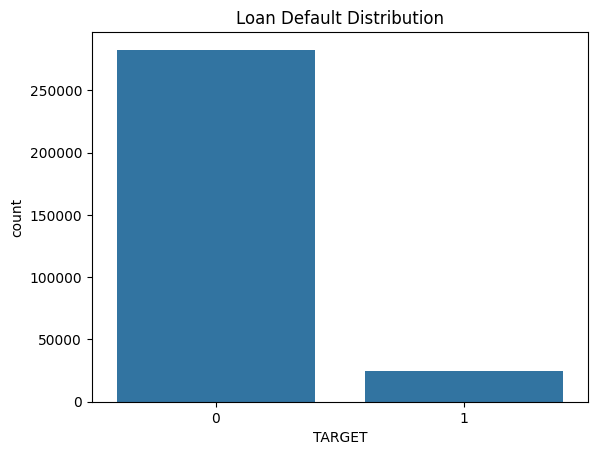

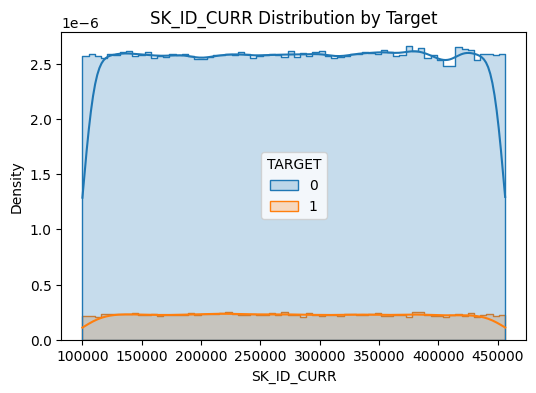

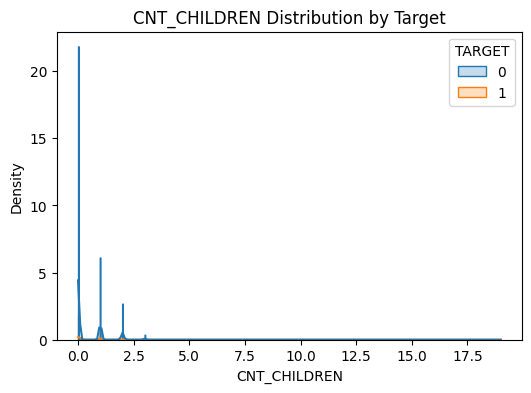

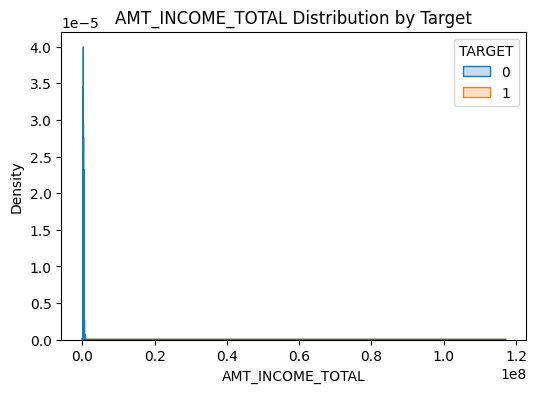

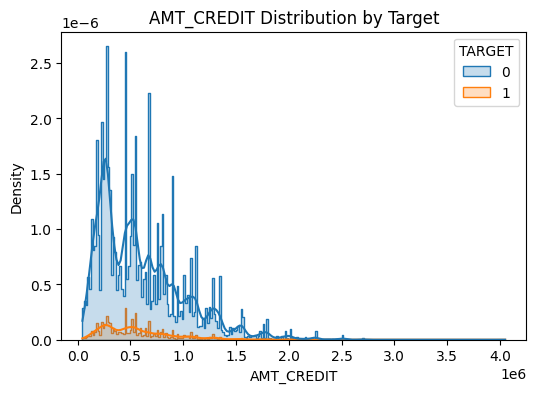

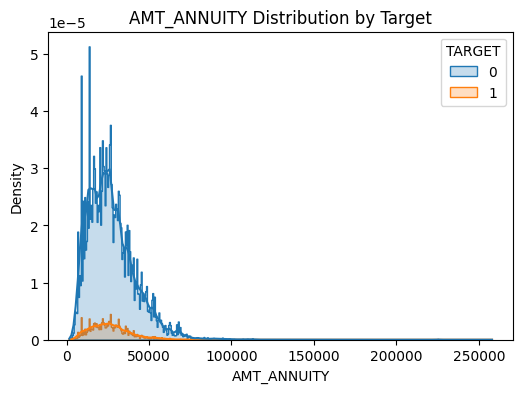

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='TARGET', data=df)
plt.title("Loan Default Distribution")
plt.show()

# Example: top 5 numeric feature distributions
numeric_cols = X.select_dtypes(include=['float64','int64']).columns[:5]
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df, x=col, hue='TARGET', kde=True, element="step", stat="density")
    plt.title(f"{col} Distribution by Target")
    plt.show()


# 4. Model Building

In [10]:
# 4. Model Training
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# Logistic Regression (scaled features)
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)
y_pred_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

# CatBoost (original features)
cat_model = CatBoostClassifier(verbose=0)
cat_model.fit(X_train, y_train)
y_pred_prob_cat = cat_model.predict_proba(X_test)[:,1]


# 5. Business Cost Optimization

Optimal Threshold - Logistic Regression: 0.16
Optimal Threshold - CatBoost: 0.16


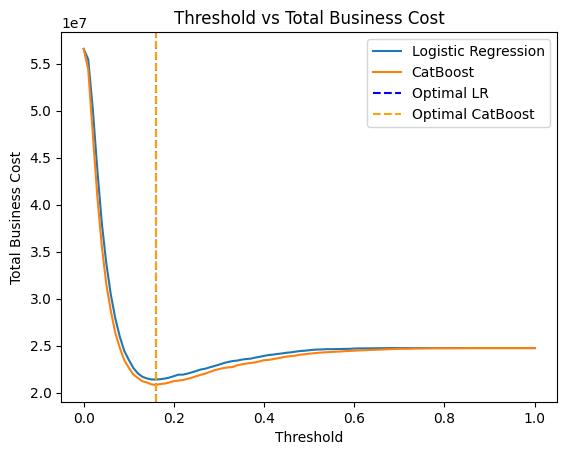

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np

cost_fp = 1000  # Approving bad loan
cost_fn = 5000  # Rejecting good applicant

def total_cost(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp*cost_fp + fn*cost_fn

thresholds = np.linspace(0,1,101)

# Logistic Regression
costs_log = [total_cost(y_test, y_pred_prob_log, t) for t in thresholds]
optimal_threshold_log = thresholds[np.argmin(costs_log)]

# CatBoost
costs_cat = [total_cost(y_test, y_pred_prob_cat, t) for t in thresholds]
optimal_threshold_cat = thresholds[np.argmin(costs_cat)]

print("Optimal Threshold - Logistic Regression:", optimal_threshold_log)
print("Optimal Threshold - CatBoost:", optimal_threshold_cat)

# Plot threshold vs cost
plt.plot(thresholds, costs_log, label='Logistic Regression')
plt.plot(thresholds, costs_cat, label='CatBoost')
plt.axvline(optimal_threshold_log, color='blue', linestyle='--', label='Optimal LR')
plt.axvline(optimal_threshold_cat, color='orange', linestyle='--', label='Optimal CatBoost')
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")
plt.title("Threshold vs Total Business Cost")
plt.legend()
plt.show()


# 6. Model Evaluation

=== Logistic Regression ===
Confusion Matrix:
[[50958  5596]
 [ 3161  1788]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     56554
           1       0.24      0.36      0.29      4949

    accuracy                           0.86     61503
   macro avg       0.59      0.63      0.61     61503
weighted avg       0.89      0.86      0.87     61503

=== CatBoost ===
Confusion Matrix:
[[50845  5709]
 [ 3024  1925]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     56554
           1       0.25      0.39      0.31      4949

    accuracy                           0.86     61503
   macro avg       0.60      0.64      0.61     61503
weighted avg       0.89      0.86      0.87     61503



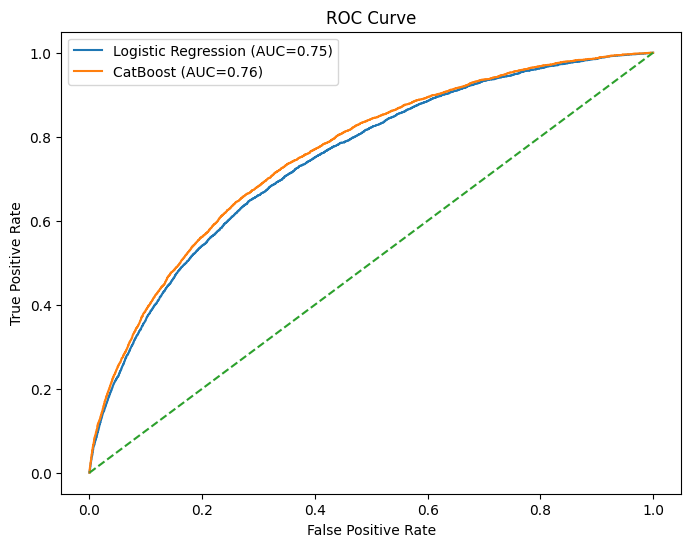

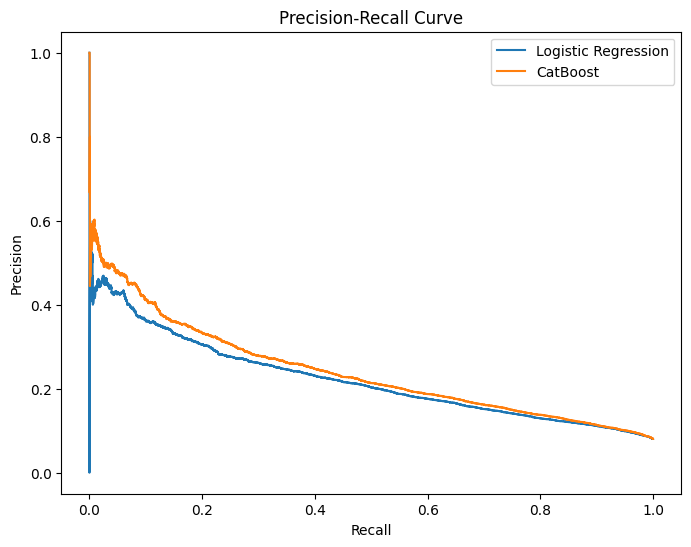

In [12]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve

def evaluate_model(y_true, y_prob, threshold, model_name):
    y_pred_opt = (y_prob >= threshold).astype(int)
    print(f"=== {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred_opt))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_opt))

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    return fpr, tpr, auc_score, precision, recall

fpr_log, tpr_log, auc_log, precision_log, recall_log = evaluate_model(y_test, y_pred_prob_log, optimal_threshold_log, "Logistic Regression")
fpr_cat, tpr_cat, auc_cat, precision_cat, recall_cat = evaluate_model(y_test, y_pred_prob_cat, optimal_threshold_cat, "CatBoost")

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={auc_log:.2f})")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC={auc_cat:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Plot Precision-Recall curves
plt.figure(figsize=(8,6))
plt.plot(recall_log, precision_log, label="Logistic Regression")
plt.plot(recall_cat, precision_cat, label="CatBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


# 7. Feature Importance

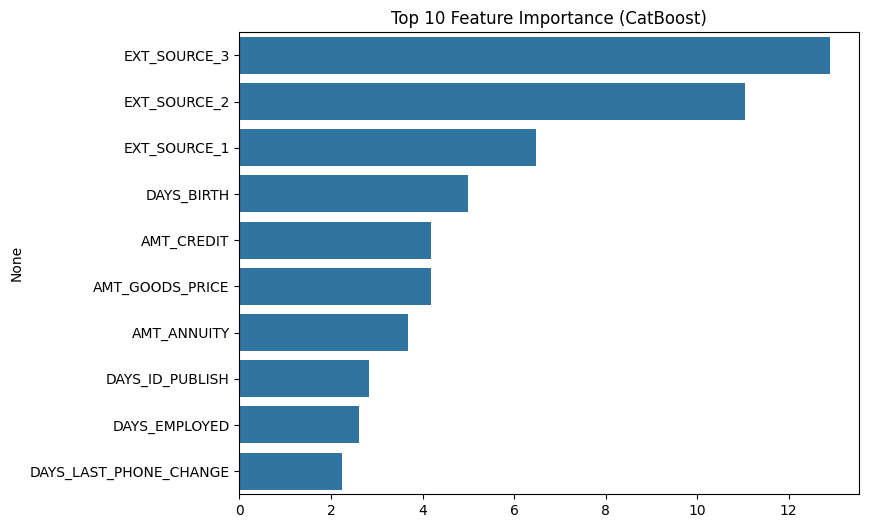

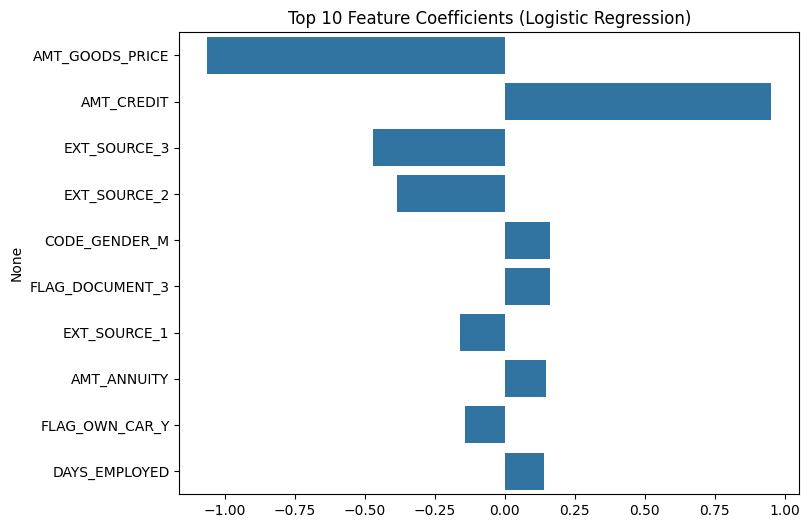

In [13]:
import seaborn as sns

# CatBoost
feature_importances = cat_model.get_feature_importance()
features = X_train.columns
top_indices = feature_importances.argsort()[-10:][::-1]  # Top 10

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importances[top_indices], y=features[top_indices])
plt.title("Top 10 Feature Importance (CatBoost)")
plt.show()

# Logistic Regression coefficients
coefficients = log_model.coef_[0]
top_indices_lr = np.abs(coefficients).argsort()[-10:][::-1]

plt.figure(figsize=(8,6))
sns.barplot(x=coefficients[top_indices_lr], y=features[top_indices_lr])
plt.title("Top 10 Feature Coefficients (Logistic Regression)")
plt.show()


# 8. Compare Total Business Costs at Optimal Thresholds

Total Business Cost - Logistic Regression: 21401000
Total Business Cost - CatBoost: 20829000


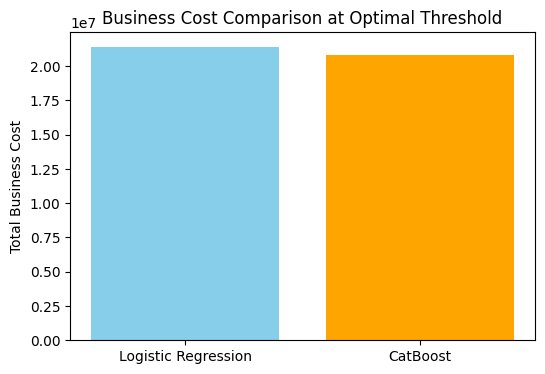

In [14]:
total_cost_log = total_cost(y_test, y_pred_prob_log, optimal_threshold_log)
total_cost_cat = total_cost(y_test, y_pred_prob_cat, optimal_threshold_cat)

print("Total Business Cost - Logistic Regression:", total_cost_log)
print("Total Business Cost - CatBoost:", total_cost_cat)

# Bar plot comparison
models = ['Logistic Regression', 'CatBoost']
costs = [total_cost_log, total_cost_cat]

plt.figure(figsize=(6,4))
plt.bar(models, costs, color=['skyblue','orange'])
plt.ylabel("Total Business Cost")
plt.title("Business Cost Comparison at Optimal Threshold")
plt.show()


# 9. Summary Table of Metrics for Both Models

In [15]:
# 9. Summary Table of Metrics for Both Models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def model_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_prob),
        'Total Business Cost': total_cost(y_true, y_prob, threshold)
    }

metrics_log = model_metrics(y_test, y_pred_prob_log, optimal_threshold_log)
metrics_cat = model_metrics(y_test, y_pred_prob_cat, optimal_threshold_cat)

summary_df = pd.DataFrame([metrics_log, metrics_cat], index=['Logistic Regression', 'CatBoost'])
summary_df = summary_df.round(3)

print("=== Model Comparison Summary ===")
display(summary_df)


=== Model Comparison Summary ===


,Accuracy,Precision,Recall,F1-Score,AUC,Total Business Cost
Logistic Regression,0.858,0.242,0.361,0.290,0.746,21401000
CatBoost,0.858,0.252,0.389,0.306,0.759,20829000


# 10. Visual Comparison of Metrics

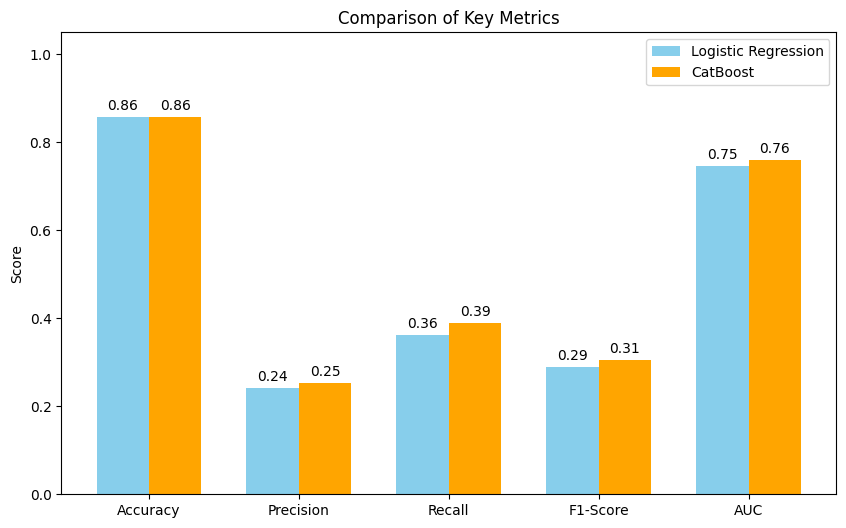

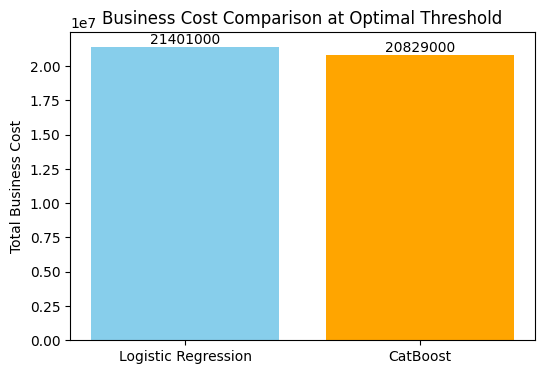

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to visualize (excluding Total Business Cost for separate scale)
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics_to_plot))  # Metric positions
width = 0.35  # Bar width

fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, summary_df.loc['Logistic Regression', metrics_to_plot], width, label='Logistic Regression', color='skyblue')
bars2 = ax.bar(x + width/2, summary_df.loc['CatBoost', metrics_to_plot], width, label='CatBoost', color='orange')

# Add labels
ax.set_ylabel('Score')
ax.set_title('Comparison of Key Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0,1.05)
ax.legend()

# Add numeric labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

# Separate bar for Total Business Cost
plt.figure(figsize=(6,4))
plt.bar(summary_df.index, summary_df['Total Business Cost'], color=['skyblue','orange'])
plt.ylabel("Total Business Cost")
plt.title("Business Cost Comparison at Optimal Threshold")
for i, v in enumerate(summary_df['Total Business Cost']):
    plt.text(i, v + 50, f"{v:.0f}", ha='center', va='bottom')
plt.show()


In [17]:
import joblib
from catboost import CatBoostClassifier
from google.colab import files

# -------------------------------
# Save Logistic Regression
# -------------------------------
joblib.dump(log_model, 'log_model.pkl')
files.download('log_model.pkl')  # Automatically downloads to your computer

# -------------------------------
# Save CatBoost
# -------------------------------
cat_model.save_model('cat_model.cbm')
files.download('cat_model.cbm')  # Automatically downloads to your computer


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import joblib
from google.colab import files

# Save the trained scaler
joblib.dump(scaler, "scaler.pkl")

# Download the scaler file
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>